[INFO] Loading predictions for visualization...
[INFO] Rendering chart...


C:\Users\rafal\AppData\Local\Temp\ipykernel_92568\356152760.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Home_Prob', y='Matchup', data=df, palette='viridis')


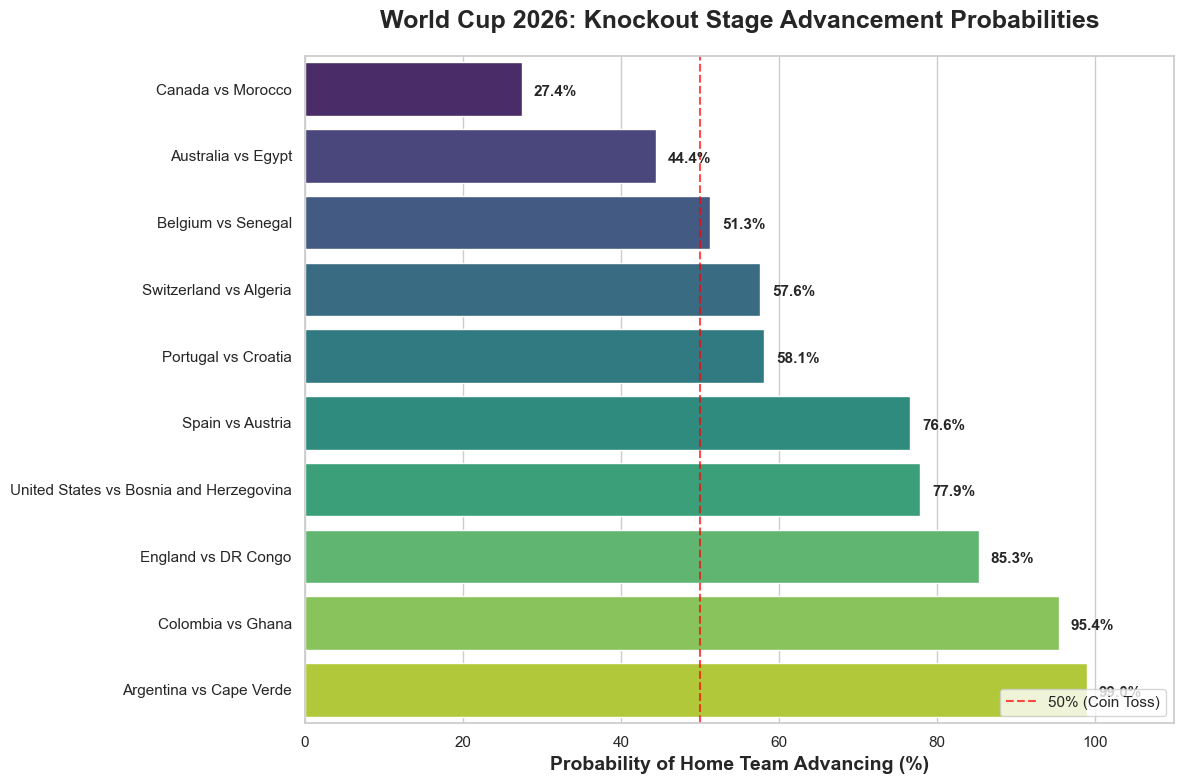

 VISUALIZATION GENERATED SUCCESSFULLY
High-resolution chart saved to: c:\Users\rafal\OneDrive\Pulpit\world-cup-predictor\data\processed\knockout_probabilities_chart.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Flexible Paths Configuration
BASE_DIR = Path.cwd().parent
if not (BASE_DIR / "data" / "processed").exists():
    BASE_DIR = Path.cwd()

PREDICTIONS_PATH = BASE_DIR / "data" / "processed" / "knockout_predictions.csv"
OUTPUT_CHART_PATH = BASE_DIR / "data" / "processed" / "knockout_probabilities_chart.png"

print("[INFO] Loading predictions for visualization...")
df = pd.read_csv(PREDICTIONS_PATH)

# 2. Data Preparation for Plotting
# Strip the '%' sign and convert to float for the graphing library
df['Home_Prob'] = df['Home_Advancement_Chance'].str.rstrip('%').astype(float)

# Create a clean label combining both teams (e.g., "England vs DR Congo")
df['Matchup'] = df['home_team'] + " vs " + df['away_team']

# Sort the dataset so the most one-sided matches are at the top
df = df.sort_values('Home_Prob', ascending=True)

# 3. Generating the Visualization
print("[INFO] Rendering chart...")
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Create a horizontal barplot using the viridis color palette
ax = sns.barplot(x='Home_Prob', y='Matchup', data=df, palette='viridis')

# 4. Professional Formatting
plt.title("World Cup 2026: Knockout Stage Advancement Probabilities", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Probability of Home Team Advancing (%)", fontsize=14, fontweight='bold')
plt.ylabel("", fontsize=12)
plt.xlim(0, 110) # Extended slightly to make room for text labels

# Add a vertical "Coin Toss" line at 50%
plt.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% (Coin Toss)')
plt.legend(loc='lower right')

# Add explicit percentage text on the end of each bar
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 1.5, p.get_y() + p.get_height() / 2. + 0.1,
             f'{width:.1f}%', ha="left", fontsize=11, fontweight='bold')

plt.tight_layout()

# 5. Save the output
plt.savefig(OUTPUT_CHART_PATH, dpi=300, bbox_inches='tight')
plt.show()

print(" VISUALIZATION GENERATED SUCCESSFULLY")
print("="*50)
print(f"High-resolution chart saved to: {OUTPUT_CHART_PATH}")